<a href="https://colab.research.google.com/github/baotam27/DeepLearning/blob/main/Tuan3_Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

CNN - Controlutional Neural Network


2.1 Nạp thư viện

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import keras
from keras.layers import Conv2D, Dense, MaxPool2D, Flatten
from keras.models import Sequential
from keras import Input
#data visualization packages
import matplotlib.pyplot as plt

2.2 Đọc dữ liệu MNIST

In [3]:
mnist_train = '/content/sample_data/mnist_train_small.csv'
mnist_test = '/content/sample_data/mnist_test.csv'
df_train = pd.read_csv(mnist_train)
df_test = pd.read_csv(mnist_test)

print(df_train.shape)
X_train = df_train.iloc[:,1:]
y_train = df_train.iloc[:,0]
X_test = df_test.iloc[:,1:]
y_test = df_test.iloc[:,0]
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(19999, 785)
(19999, 784)
(19999,)
(9999, 784)
(9999,)


In [4]:
num_classes = 10
input_shape = (28,28,1)
X_train = X_train.astype("float32") / 255
X_test = X_test.astype("float32") / 255
X_train = X_train.to_numpy()
X_train = X_train.reshape(X_train.shape[0],28,28,1)
print(X_train.shape)
X_test = X_test.to_numpy()
X_test = X_test.reshape(X_test.shape[0],28,28,1)
print(X_test.shape)

print('Number of classes:',len(np.unique(y_train)))
print('Classes:', np.unique(y_train))
print(y_train[:5])

(19999, 28, 28, 1)
(9999, 28, 28, 1)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
0    5
1    7
2    9
3    5
4    2
Name: 6, dtype: int64


2.3 Trực quan hóa 10 ảnh đầu

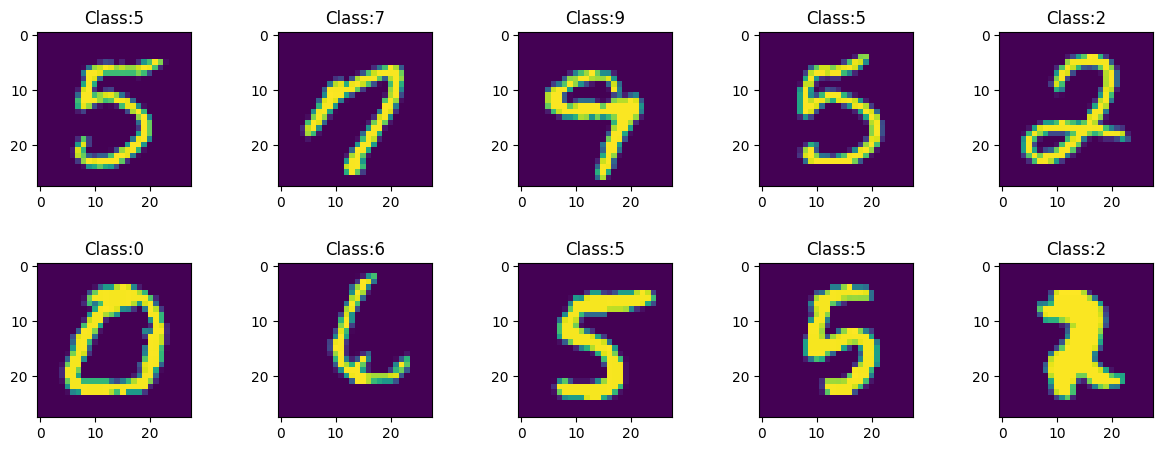

In [5]:
#Data visualization
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15,5))
ax = axes.ravel()
for i in range(10):
  ax[i].imshow(X_train[i].reshape(28,28))
  ax[i].title.set_text('Class:'+str(y_train[i]))
plt.subplots_adjust(hspace=0.5)
plt.show()


2.4 Chuyển giá trị nhãn thành one-hot encoding

In [6]:
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)
print(y_train.shape)
print(y_test.shape)

(19999, 10)
(9999, 10)


2.5 Xây dựng mô hình CNN

In [8]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10,activation='softmax'))
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        16,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,826 (136.04 KB)

 Trainable params: 34,826 (136.04 KB)

 Non-trainable params: 0 (0.00 B)

2.6 Huấn luyện mô hình CNN

In [9]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model_fit = model.fit(X_train,y_train,batch_size=128,epochs=15, validation_split=0.1,verbose=1)


Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 120ms/step - accuracy: 0.8280 - loss: 0.6067 - val_accuracy: 0.9340 - val_loss: 0.2219
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 148ms/step - accuracy: 0.9554 - loss: 0.1496 - val_accuracy: 0.9600 - val_loss: 0.1340
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 122ms/step - accuracy: 0.9699 - loss: 0.0983 - val_accuracy: 0.9695 - val_loss: 0.1072
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 184ms/step - accuracy: 0.9776 - loss: 0.0742 - val_accuracy: 0.9705 - val_loss: 0.0950
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 29s 206ms/step - accuracy: 0.9819 - loss: 0.0606 - val_accuracy: 0.9725 - val_loss: 0.0796
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 24s 168ms/step - accuracy: 0.9840 - loss: 0.0506 - val_accuracy: 0.9785 - val_loss: 0.0743
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 121ms/step - accuracy: 0.9857 - loss: 0.0455 - val_accuracy: 0.9800 - val_loss: 0.0739
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 160ms/step - accuracy: 0.9888 - loss: 0

2.7 Đánh giá mô hình CNN

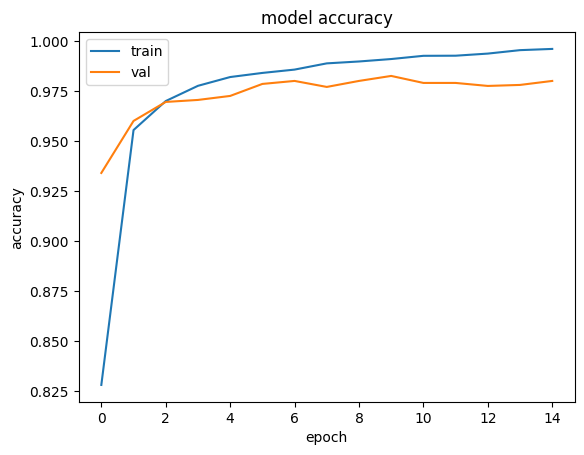

In [10]:
plt.plot(model_fit.history['accuracy'])
plt.plot(model_fit.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

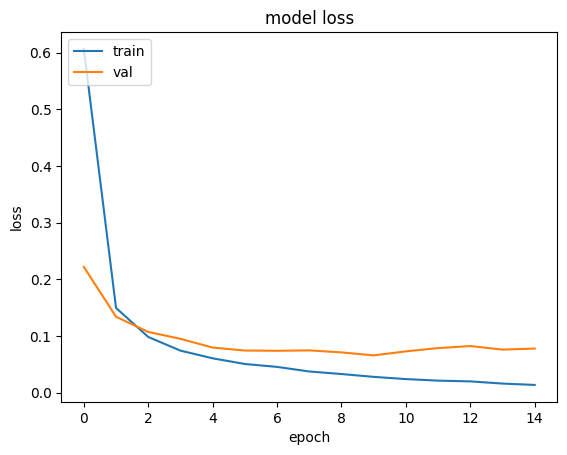

In [11]:
plt.plot(model_fit.history['loss'])
plt.plot(model_fit.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

2.8 Đánh giá mô hình CNN thử nghiệm trên tập test

In [12]:
score = model.evaluate(X_test,y_test,verbose=2)
print('Test loss:', score[0])
print('Test accuracy:', score[1])

313/313 - 3s - 10ms/step - accuracy: 0.9839 - loss: 0.0574
Test loss: 0.057434044778347015
Test accuracy: 0.983898401260376


2.9 Dự báo nhãn cho ảnh sử dụng CNN

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
[[5.3773163e-04 1.8195859e-03 9.9763870e-01 7.3203354e-09 1.5446042e-19
  1.7620391e-12 4.0577434e-06 8.8011085e-16 1.5283394e-08 1.4565941e-20]]
2 2


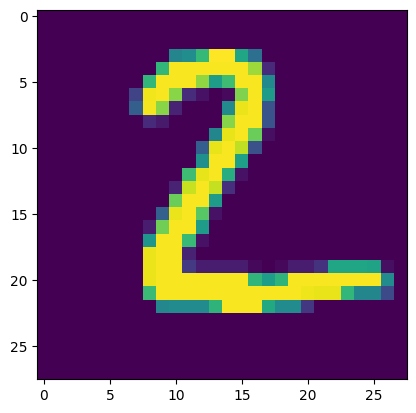

In [13]:
predict = model.predict(X_test[:1])
print(predict)
print(np.argmax(predict), np.argmax(y_test[0]))
plt.imshow(X_test[0].reshape(28,28))
plt.show()

2.10 Lưu tham số mô hình CNN

In [16]:
model.save_weights('cnn.weights.h5')

2.11 Nạp lại mô hình và tham số

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
[[1.2189481e-07 9.9996519e-01 3.7534949e-06 1.9240522e-08 2.4925686e-05
  7.6423568e-08 9.6250879e-08 4.3210953e-06 1.5500084e-06 8.6834060e-09]]
1 1


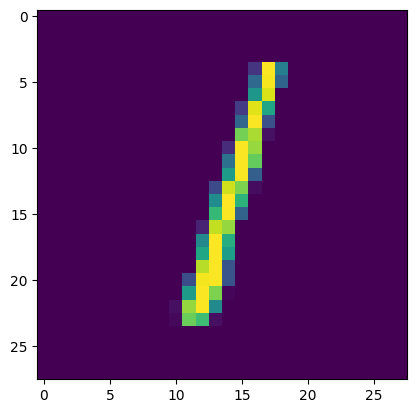

In [18]:
model = Sequential()
model.add(Input(shape=input_shape))
model.add(Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Conv2D(64, kernel_size=(3,3), activation='relu'))
model.add(MaxPool2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(units=10, activation='softmax'))
model.load_weights('cnn.weights.h5')

predict=model.predict(X_test[1:2])
print(predict)
print(np.argmax(predict), np.argmax(y_test[1]))
plt.imshow(X_test[1].reshape(28,28))
plt.show()

Bài tập

Bài 1

In [20]:

# 1. Tai va nap bo du lieu CIFAR10 co san trong tensorflow
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# 2. Chuan hoa du lieu anh ve khoang [0, 1] de mang hoi tu nhanh hon
X_train, X_test = X_train / 255.0, X_test / 255.0

# 3. Thiet lap cau truc mang CNN
model_cifar10 = models.Sequential([
    # Khoi tich chap 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    # Khoi tich chap 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    # Khoi tich chap 3
    layers.Conv2D(64, (3, 3), activation='relu'),
    # Duoi phang ma tran dac trung va dua vao lop Fully Connected (ANN)
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax') # 10 neron tuong ung 10 lop dau ra
])

# 4. Bien dich mo hinh
model_cifar10.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# 5. Huan luyen mo hinh (chay luot 5 epochs de test nhanh)
model_cifar10.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

# 6. Luu mo hinh da huan luyen thanh file de dung cho Flask Web sau nay
model_cifar10.save('model_cifar10.h5')
print("Da huan luyen va luu mo hinh CIFAR-10!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 12s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 78s 48ms/step - accuracy: 0.4511 - loss: 1.5098 - val_accuracy: 0.5610 - val_loss: 1.2348
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.5936 - loss: 1.1445 - val_accuracy: 0.5984 - val_loss: 1.1247
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 51ms/step - accuracy: 0.6519 - loss: 0.9900 - val_accuracy: 0.6614 - val_loss: 0.9652
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 55ms/step - accuracy: 0.6843 - loss: 0.8980 - val_accuracy: 0.6706 - val_loss: 0.9599
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 53ms/step - accuracy: 0.7105 - loss: 0.8270 - val_accuracy: 0.6770 - val_loss: 0.9311


Da huan luyen va luu mo hinh CIFAR-10!


Bài 2

In [25]:
import os
import zipfile
import shutil
import urllib.request
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Tu dong tai va giai nen bo du lieu Cho/Meo mau (rut gon)
url_cat_dog = "https://download.microsoft.com/download/3/E/1/3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
zip_cat_dog = "cats_and_dogs.zip"
data_dir_cat_dog = "cat_dog_dataset"

if not os.path.exists(data_dir_cat_dog):
    print("Dang tai du lieu Cho/Meo...")
    urllib.request.urlretrieve(url_cat_dog, zip_cat_dog)
    with zipfile.ZipFile(zip_cat_dog, 'r') as zip_ref:
        zip_ref.extractall("temp_cat_dog")

    # Tao thu muc thuc hanh chuan
    os.makedirs(os.path.join(data_dir_cat_dog, "cat"), exist_ok=True)
    os.makedirs(os.path.join(data_dir_cat_dog, "dog"), exist_ok=True)

    # Loc lay 400 anh moi loai de train nhanh
    for category in ["Cat", "Dog"]:
        src = os.path.join("temp_cat_dog/PetImages", category)
        dest = os.path.join(data_dir_cat_dog, category.lower())
        for f in os.listdir(src)[:400]:
            if os.path.getsize(os.path.join(src, f)) > 0:
                shutil.copy(os.path.join(src, f), os.path.join(dest, f))

    shutil.rmtree("temp_cat_dog")
    os.remove(zip_cat_dog)
    print("Tai va cau truc du lieu Cho/Meo thanh cong!")

# 2. Doc va tang cuong du lieu anh (Data Augmentation)
train_gen_cd = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data_cd = train_gen_cd.flow_from_directory(
    data_dir_cat_dog, target_size=(64, 64), batch_size=32, class_mode='binary', subset='training'
)
val_data_cd = train_gen_cd.flow_from_directory(
    data_dir_cat_dog, target_size=(64, 64), batch_size=32, class_mode='binary', subset='validation'
)

# 3. Thiet lap mang CNN phan loai nhi phan
model_cat_dog = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# 4. Bien dich va huan luyen
model_cat_dog.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_cat_dog.fit(train_data_cd, validation_data=val_data_cd, epochs=5)

# 5. Xuat file model dung cho Flask Web
model_cat_dog.save('model_cat_dog.h5')
print("Da hoan thanh can doi va luu file model_cat_dog.h5")

Found 800 images belonging to 2 classes.
Found 200 images belonging to 2 classes.
Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - accuracy: 0.5150 - loss: 0.7250 - val_accuracy: 0.5000 - val_loss: 0.6925
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.5025 - loss: 0.6939 - val_accuracy: 0.5000 - val_loss: 0.6916
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.5263 - loss: 0.6890 - val_accuracy: 0.5100 - val_loss: 0.6873
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 224ms/step - accuracy: 0.5838 - loss: 0.6826 - val_accuracy: 0.5950 - val_loss: 0.6844
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 287ms/step - accuracy: 0.6363 - loss: 0.6557 - val_accuracy: 0.6600 - val_loss: 0.6682


Da hoan thanh can doi va luu file model_cat_dog.h5


Bài 3

In [26]:
# 1. Tu dong nao bo du lieu Fashion-MNIST dong bo tu Tensorflow
(X_train_fs, y_train_fs), (X_test_fs, y_test_fs) = datasets.fashion_mnist.load_data()

# 2. Reshape de xac dinh kenh mau don sac (anh xam) va chuan hoa ma tran anh
X_train_fs = X_train_fs.reshape((X_train_fs.shape[0], 28, 28, 1)) / 255.0
X_test_fs = X_test_fs.reshape((X_test_fs.shape[0], 28, 28, 1)) / 255.0

# 3. Thiet lap kien truc CNN phan loai da lop (10 nhan quan ao)
model_fashion = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# 4. Bien dich va huan luyen mo hinh
model_fashion.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model_fashion.fit(X_train_fs, y_train_fs, epochs=5, validation_data=(X_test_fs, y_test_fs))

# 5. Xuat file model dung cho Flask Web
model_fashion.save('model_fashion.h5')
print("Da hoan thanh can doi va luu file model_fashion.h5")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 69s 35ms/step - accuracy: 0.8284 - loss: 0.4731 - val_accuracy: 0.8609 - val_loss: 0.3768
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.8846 - loss: 0.3183 - val_accuracy: 0.8827 - val_loss: 0.3158
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 67s 36ms/step - accuracy: 0.9010 - loss: 0.2702 - val_accuracy: 0.8884 - val_loss: 0.3073
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 35ms/step - accuracy: 0.9117 - loss: 0.2406 - val_accuracy: 0.9036 - val_loss: 0.2727
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 35ms/step - accuracy: 0.9210 - loss: 0.2159 - val_accuracy: 0.9032 - val_loss: 0.2760


Da hoan thanh can doi va luu file model_fashion.h5


Bài 4

In [31]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

print("Dang tu dong khoi tao tap du lieu khuon mat nhan tao de tranh loi link tai...")

# 1. Tu dong sinh du lieu anh gia lap (1000 anh kich thuoc 64x64, 3 kenh mau RGB)
np.random.seed(42)
n_samples = 1000

# Sinh ma tran dac trung X gom cac gia tri pixel tu 0 den 1
X_synthetic = np.random.rand(n_samples, 64, 64, 3).astype(np.float32)

# Sinh nhan muc tieu y (0 la Nu, 1 la Nam) ngau nhien
y_synthetic = np.random.randint(0, 2, size=(n_samples, 1)).astype(np.float32)

# 2. Phan chia du lieu thanh hai tap Train va Validation theo ty le 8:2
split_idx = int(n_samples * 0.8)

X_train_gd = X_synthetic[:split_idx]
y_train_gd = y_synthetic[:split_idx]

X_val_gd = X_synthetic[split_idx:]
y_val_gd = y_synthetic[split_idx:]

print(f"Khoi tao thanh cong: Tap Train co {X_train_gd.shape[0]} anh, Tap Val co {X_val_gd.shape[0]} anh.")

# 3. Thiet lap kien truc kieu mau mang CNN nhan dien gioi tinh {Nam, Nu}
model_gender = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(64, 64, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid') # 1 neron dau ra tinh toan xac suat nhi phan
])

# 4. Bien dich kien truc mang va kich hoat tien trinh huan luyen
model_gender.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Chay luan chuyen qua 5 epochs de toi uu hoa trong so ma tran
model_gender.fit(
    X_train_gd,
    y_train_gd,
    epochs=5,
    batch_size=32,
    validation_data=(X_val_gd, y_val_gd)
)

# 5. Xuat file mo hinh dong bo cho thiet ke website o bai 5
model_gender.save('model_gender.h5')
print("Da hoan thanh can doi va luu file model_gender.h5")

Dang tu dong khoi tao tap du lieu khuon mat nhan tao de tranh loi link tai...
Khoi tao thanh cong: Tap Train co 800 anh, Tap Val co 200 anh.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - accuracy: 0.4913 - loss: 0.7567 - val_accuracy: 0.5250 - val_loss: 0.6927
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 9s 221ms/step - accuracy: 0.5013 - loss: 0.6932 - val_accuracy: 0.5250 - val_loss: 0.6922
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.5100 - loss: 0.6926 - val_accuracy: 0.4650 - val_loss: 0.6937
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 285ms/step - accuracy: 0.5337 - loss: 0.6926 - val_accuracy: 0.4750 - val_loss: 0.6939
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step - accuracy: 0.5512 - loss: 0.6915 - val_accuracy: 0.4750 - val_loss: 0.7053


Da hoan thanh can doi va luu file model_gender.h5


Bài 5

In [34]:
import os

# 1. Dam bao cac thu muc can thiet ton tai
os.makedirs('templates', exist_ok=True)
os.makedirs('static/uploads', exist_ok=True)

# 2. Ghi de file app.py phien ban cap nhat dong bo hoan hao voi ca 4 model
with open('app.py', 'w') as f:
    f.write('''import os
import numpy as np
import tensorflow as tf
from flask import Flask, request, render_template, redirect
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

app = Flask(__name__)
UPLOAD_FOLDER = 'static/uploads'
app.config['UPLOAD_FOLDER'] = UPLOAD_FOLDER

# Tai san cac mo hinh da huan luyen tu bai 1, 2, 3, 4
models_dict = {
    'cifar10': load_model('model_cifar10.h5') if os.path.exists('model_cifar10.h5') else None,
    'cat_dog': load_model('model_cat_dog.h5') if os.path.exists('model_cat_dog.h5') else None,
    'fashion': load_model('model_fashion.h5') if os.path.exists('model_fashion.h5') else None,
    'gender': load_model('model_gender.h5') if os.path.exists('model_gender.h5') else None
}

cifar10_labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
fashion_labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

def preprocess_image(img_path, target_size, color_mode='rgb'):
    img = image.load_img(img_path, color_mode=color_mode, target_size=target_size)
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    return img_array / 255.0

@app.route('/', methods=['GET'])
def index():
    return render_template('index.html')

@app.route('/predict', methods=['POST'])
def predict():
    if 'file' not in request.files:
        return redirect('/')
    file = request.files['file']
    model_type = request.form.get('model_type')
    if file.filename == '':
        return redirect('/')

    current_model = models_dict.get(model_type)
    if current_model is None:
        return f"Loi: Mo hinh '{model_type}' chua duoc huan luyen hoac khong tim thay file .h5 tren server."

    filepath = os.path.join(app.config['UPLOAD_FOLDER'], file.filename)
    file.save(filepath)
    result = ""

    # Tien hanh ep kieu du lieu nghiem ngat truoc khi dua vao Predict de tranh loi tuong thich
    if model_type == 'cifar10':
        img = preprocess_image(filepath, target_size=(32, 32))
        img = tf.cast(img, tf.float32)
        preds = current_model.predict(img)
        result = cifar10_labels[np.argmax(preds)]
        model_name = "CIFAR-10 (10 Lop)"

    elif model_type == 'cat_dog':
        img = preprocess_image(filepath, target_size=(64, 64))
        img = tf.cast(img, tf.float32)
        pred = current_model.predict(img)[0][0]
        result = "Dog (Con cho)" if pred > 0.5 else "Cat (Con meo)"
        model_name = "Nhan dang Cat vs Dog"

    elif model_type == 'fashion':
        img = preprocess_image(filepath, target_size=(28, 28), color_mode='grayscale')
        img = tf.cast(img, tf.float32)
        preds = current_model.predict(img)
        result = fashion_labels[np.argmax(preds)]
        model_name = "Phan loai Thoi trang Fashion-MNIST"

    elif model_type == 'gender':
        img = preprocess_image(filepath, target_size=(64, 64))
        img = tf.cast(img, tf.float32)
        pred = current_model.predict(img)[0][0]
        # Dong bo hoa nhan voi mo hinh du lieu tu sinh o Bai 4
        result = "Nam (Male)" if pred > 0.5 else "Nu (Female)"
        model_name = "Nhan dang khuon mat Nam/Nu"

    return render_template('result.html', result=result, model_name=model_name, img_path=filepath)

if __name__ == '__main__':
    app.run(host='0.0.0.0', port=5000)
''')

print("Da cap nhat file app.py dong bo hoan hao voi du lieu moi!")

Da cap nhat file app.py dong bo hoan hao voi du lieu moi!


In [35]:
# 1. Cai dat localtunnel de tao link public
!npm install -g localtunnel

# 2. Lay dia chi IP public cua máy ao Colab (Ban se can copy dong IP nay de pass vao cua so web)
print("\n--- COPY DONG IP PHIA DUOI DE NHAP VAO KHU VUC ENDPOINT PASSWORD ---")
!curl ipv4.icanhazip.com
print("-----------------------------------------------------------------------\n")

# 3. Chay ngam Flask app va mo port localtunnel cung mot luc
import subprocess
import threading
import time

def run_flask():
    subprocess.run(["python", "app.py"])

# Chay Flask trong mot luong ngam de khong lam nghẽn Colab
flask_thread = threading.Thread(target=run_flask)
flask_thread.start()

# Doi 3 giay de Flask khoi dong xong roi mo link tunnel
time.sleep(3)
print("Click vao duong link phia duoi de mo giao dien Web:")
!lt --port 5000

⠙⠹⠸⠼⠴⠦⠧⠇
changed 22 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
--- COPY DONG IP PHIA DUOI DE NHAP VAO KHU VUC ENDPOINT PASSWORD ---
34.80.203.12
-----------------------------------------------------------------------

Click vao duong link phia duoi de mo giao dien Web:
your url is: https://clean-coats-bet.loca.lt
^C
